In [1]:
from ximea import xiapi
from workers.camera import XimeaCamera, single_roi_config, full_frame_config, multi_roi_config, make_rois
import time

In [2]:
import matplotlib.pyplot as plt
from IPython import display
import numpy as np

In [12]:
# Define configs
ffi_cfg = full_frame_config(exposure_us = 1000, frame_rate_hz = 5)
single_cfg = single_roi_config(width = 848, height = 848, offset_x = 1992, offset_y = 1992, exposure_us = 1000, frame_rate_hz = 100)

rois = make_rois()
multi_cfg = multi_roi_config(rois = rois, exposure_us = 1000, frame_rate_hz = 100)

In [4]:
rois

[RoiDefinition(height=360, offset_y=0, width=360, offset_x=0, label='top_left', is_data=True),
 RoiDefinition(height=360, offset_y=0, width=128, offset_x=2192, label='top_mid', is_data=False),
 RoiDefinition(height=360, offset_y=0, width=360, offset_x=4152, label='top_right', is_data=True),
 RoiDefinition(height=128, offset_y=2192, width=360, offset_x=0, label='mid_left', is_data=False),
 RoiDefinition(height=128, offset_y=2192, width=128, offset_x=2192, label='centre', is_data=True),
 RoiDefinition(height=128, offset_y=2192, width=360, offset_x=4152, label='mid_right', is_data=False),
 RoiDefinition(height=360, offset_y=4152, width=360, offset_x=0, label='bot_left', is_data=True),
 RoiDefinition(height=360, offset_y=4152, width=128, offset_x=2192, label='bot_mid', is_data=False),
 RoiDefinition(height=360, offset_y=4152, width=360, offset_x=4152, label='bot_right', is_data=True)]

In [7]:
times = []
with XimeaCamera(ffi_cfg) as cam:
    for _ in range(10):
        frame = cam.acquire_frame()
        print(frame.frame_id, frame.timestamp_ns, frame.host_time, frame.mode, frame.nframes_dropped)
        times.append(frame.timestamp_ns)

xiAPI: ---- xiOpenDevice API:V4.32.00.00 started ----
xiAPI: EAL_IF_xiFAPI_Top::InitializeDevice sn:CENAU2612001 name:MC203MG-SY-UB
xiAPI: XiApiToGentlParamModel::UpdateQueueSize Warning: buffers_queue_size was limited by acq_buffer_size to 3
xiAPI: FGTL_SetParam_to_CAL error from CAL: -1015, addr:x27317e
xiAPI: XiApiToGentlParamModel Auto bandwidth measurement finished (396MBps). Safe limit set to: 317MBps
xiAPI: FGTL_SetParam_to_CAL error from CAL: -10009, addr:x201380
xiAPI: ---- Device opened. Model:MC203MG-SY-UB SN:CENAU2612001 FwF1:02.07 API:V4.32.00.00 ----
xiAPI: xiFAPI_Device::AllocateBuffers Allocating buffers. Count:8 OneBuff:29823 KiB All:256 MiB Frm:x10c0047
xiAPI: Failed to change thread scheduler, check user limit for realtime priority.


1 19455063813000 19445.618495414 CameraMode.FULL_FRAME 0
2 19455264005000 19445.804535032 CameraMode.FULL_FRAME 0
3 19455464197000 19446.003997866 CameraMode.FULL_FRAME 0
4 19455664389000 19446.209989777 CameraMode.FULL_FRAME 0
5 19455864581000 19446.405253591 CameraMode.FULL_FRAME 0
6 19456064774000 19446.605284052 CameraMode.FULL_FRAME 0
7 19456264966000 19446.806442308 CameraMode.FULL_FRAME 0
8 19456465158000 19447.007951067 CameraMode.FULL_FRAME 0
9 19456665350000 19447.206363994 CameraMode.FULL_FRAME 0
10 19456865542000 19447.404166254 CameraMode.FULL_FRAME 0


xiAPI: xiCloseDevice


In [6]:
# Check frame rate
1/(np.mean(np.asarray(times)[1:]-np.asarray(times)[:-1])/1e9)

4.995199562763623

In [8]:
# Check FFI size
frame.rois['full_frame'].shape

(4512, 4512)

In [13]:
# Single ROI
times = []
with XimeaCamera(single_cfg) as cam:
    for _ in range(10):
        frame = cam.acquire_frame()
        print(frame.frame_id, frame.timestamp_ns, frame.host_time, frame.mode, frame.nframes_dropped)
        times.append(frame.timestamp_ns)

print(1/(np.mean(np.asarray(times)[1:]-np.asarray(times)[:-1])/1e9))
print(frame.rois['single_roi'].shape)

xiAPI: ---- xiOpenDevice API:V4.32.00.00 started ----
xiAPI: EAL_IF_xiFAPI_Top::InitializeDevice sn:CENAU2612001 name:MC203MG-SY-UB
xiAPI: XiApiToGentlParamModel::UpdateQueueSize Warning: buffers_queue_size was limited by acq_buffer_size to 3
xiAPI: FGTL_SetParam_to_CAL error from CAL: -1015, addr:x27317e
xiAPI: XiApiToGentlParamModel Auto bandwidth measurement finished (396MBps). Safe limit set to: 317MBps
xiAPI: FGTL_SetParam_to_CAL error from CAL: -10009, addr:x201380
xiAPI: ---- Device opened. Model:MC203MG-SY-UB SN:CENAU2612001 FwF1:02.07 API:V4.32.00.00 ----
xiAPI: xiFAPI_Device::AllocateBuffers Allocating buffers. Count:248 OneBuff:1055 KiB All:256 MiB Frm:x10c0047
xiAPI: Failed to change thread scheduler, check user limit for realtime priority.


1 20036351387000 20026.796416349 CameraMode.SINGLE_ROI 0
2 20036361460000 20026.806990329 CameraMode.SINGLE_ROI 0
3 20036371534000 20026.816845801 CameraMode.SINGLE_ROI 0
4 20036381608000 20026.826670135 CameraMode.SINGLE_ROI 0
5 20036391682000 20026.836768811 CameraMode.SINGLE_ROI 0
6 20036401755000 20026.846782717 CameraMode.SINGLE_ROI 0
7 20036411829000 20026.856922737 CameraMode.SINGLE_ROI 0
8 20036421903000 20026.866952035 CameraMode.SINGLE_ROI 0
9 20036431977000 20026.877152729 CameraMode.SINGLE_ROI 0
10 20036442050000 20026.88724206 CameraMode.SINGLE_ROI 0
99.26872042619371
(848, 848)


xiAPI: xiCloseDevice


In [11]:
# Multi ROI
# this camera doesn't have the multi-roi mode, so just check that with the current settings the single roi regions work
rois = make_rois()
multi_cfg = multi_roi_config(rois = rois, exposure_us = 1000, frame_rate_hz = 100)

for roi in rois:
    print(roi.label, roi.width, roi.height, roi.offset_x, roi.offset_y)
    single_cfg = single_roi_config(width = roi.width, height = roi.height, offset_x = roi.offset_x, offset_y = roi.offset_y, exposure_us = 1000, frame_rate_hz = 100)
    with XimeaCamera(single_cfg) as cam:
        for _ in range(10):
            frame = cam.acquire_frame()
            print(frame.frame_id, frame.timestamp_ns, frame.host_time, frame.mode, frame.nframes_dropped)

top_left 360 360 0 0


xiAPI: ---- xiOpenDevice API:V4.32.00.00 started ----
xiAPI: EAL_IF_xiFAPI_Top::InitializeDevice sn:CENAU2612001 name:MC203MG-SY-UB
xiAPI: XiApiToGentlParamModel::UpdateQueueSize Warning: buffers_queue_size was limited by acq_buffer_size to 3
xiAPI: FGTL_SetParam_to_CAL error from CAL: -1015, addr:x27317e
xiAPI: XiApiToGentlParamModel Auto bandwidth measurement finished (396MBps). Safe limit set to: 317MBps
xiAPI: FGTL_SetParam_to_CAL error from CAL: -10009, addr:x201380
xiAPI: ---- Device opened. Model:MC203MG-SY-UB SN:CENAU2612001 FwF1:02.07 API:V4.32.00.00 ----
xiAPI: xiFAPI_Device::AllocateBuffers Allocating buffers. Count:1372 OneBuff:191 KiB All:256 MiB Frm:x10c0047
xiAPI: Failed to change thread scheduler, check user limit for realtime priority.


1 19678438383000 19668.879684482 CameraMode.SINGLE_ROI 0
2 19678448457000 19668.88906385 CameraMode.SINGLE_ROI 0
3 19678458531000 19668.899179966 CameraMode.SINGLE_ROI 0
4 19678468605000 19668.909080143 CameraMode.SINGLE_ROI 0
5 19678478678000 19668.919105217 CameraMode.SINGLE_ROI 0
6 19678488752000 19668.929119252 CameraMode.SINGLE_ROI 0
7 19678498826000 19668.939341642 CameraMode.SINGLE_ROI 0
8 19678508900000 19668.949235099 CameraMode.SINGLE_ROI 0
9 19678518974000 19668.95948181 CameraMode.SINGLE_ROI 0
10 19678529047000 19668.969624486 CameraMode.SINGLE_ROI 0


xiAPI: xiCloseDevice
xiAPI: ---- xiOpenDevice API:V4.32.00.00 started ----


top_mid 128 360 2192 0


...

xiAPI: xiCloseDevice
xiAPI: ---- xiOpenDevice API:V4.32.00.00 started ----


bot_right 360 360 4152 4152


xiAPI: EAL_IF_xiFAPI_Top::InitializeDevice sn:CENAU2612001 name:MC203MG-SY-UB
xiAPI: XiApiToGentlParamModel::UpdateQueueSize Warning: buffers_queue_size was limited by acq_buffer_size to 3
xiAPI: FGTL_SetParam_to_CAL error from CAL: -1015, addr:x27317e
xiAPI: XiApiToGentlParamModel Auto bandwidth measurement finished (396MBps). Safe limit set to: 317MBps
xiAPI: FGTL_SetParam_to_CAL error from CAL: -10009, addr:x201380
xiAPI: ---- Device opened. Model:MC203MG-SY-UB SN:CENAU2612001 FwF1:02.07 API:V4.32.00.00 ----
xiAPI: xiFAPI_Device::AllocateBuffers Allocating buffers. Count:1372 OneBuff:191 KiB All:256 MiB Frm:x10c0047
xiAPI: Failed to change thread scheduler, check user limit for realtime priority.


1 19761247069000 19751.688358038 CameraMode.SINGLE_ROI 0
2 19761257142000 19751.697721309 CameraMode.SINGLE_ROI 0
3 19761267216000 19751.707810832 CameraMode.SINGLE_ROI 0
4 19761277290000 19751.717731809 CameraMode.SINGLE_ROI 0
5 19761287364000 19751.727744852 CameraMode.SINGLE_ROI 0
6 19761297437000 19751.737973002 CameraMode.SINGLE_ROI 0
7 19761307511000 19751.748208352 CameraMode.SINGLE_ROI 0
8 19761317585000 19751.758111441 CameraMode.SINGLE_ROI 0
9 19761327659000 19751.768250277 CameraMode.SINGLE_ROI 0
10 19761337732000 19751.778275032 CameraMode.SINGLE_ROI 0


xiAPI: xiCloseDevice


In [7]:
def get_camera_basic_info(cam: xiapi.Camera) -> str:
    """
    The function returns basic information about the camera and API version.
    
    :return device name, serial number, sensor serial number, api version:
    """
    if cam.is_isexist:
        name = cam.get_device_name().decode("UTF-8")
        sn = cam.get_device_sn().decode("UTF-8")
        try:
            sensor_sn = cam.get_device_sens_sn().decode("UTF-8")
        except Exception as e:
            sensor_sn = e
        api_version = cam.get_api_version().decode("UTF-8")

        return f"""
        Device Name:\t\t\t{name}
        Serial Number:\t\t\t{sn}
        Sensor Serial Number:\t\t{sensor_sn}
        Api Version:\t\t\t{api_version}
        """

In [4]:
cam = xiapi.Camera()

In [5]:
cam.open_device()

xiAPI: ---- xiOpenDevice API:V4.32.00.00 started ----
xiAPI: EAL_IF_xiFAPI_Top::InitializeDevice sn:CENAU2612001 name:MC203MG-SY-UB
xiAPI: XiApiToGentlParamModel::UpdateQueueSize Warning: buffers_queue_size was limited by acq_buffer_size to 3
xiAPI: FGTL_SetParam_to_CAL error from CAL: -1015, addr:x27317e
xiAPI: XiApiToGentlParamModel Auto bandwidth measurement finished (396MBps). Safe limit set to: 317MBps
xiAPI: FGTL_SetParam_to_CAL error from CAL: -10009, addr:x201380
xiAPI: ---- Device opened. Model:MC203MG-SY-UB SN:CENAU2612001 FwF1:02.07 API:V4.32.00.00 ----


In [6]:
print(get_camera_basic_info(cam))


        Device Name:			MC203MG-SY-UB
        Serial Number:			CENAU2612001
        Sensor Serial Number:		CENAU2612001
        Api Version:			V4.32.00.00
        


In [7]:
cam.get_height()

4512

In [8]:
cam.get_height_increment()

8

In [9]:
cam.get_offsetY()

0

In [10]:
cam.get_offsetX()

0

In [11]:
cam.get_width()

4512

In [12]:
cam.get_width_increment()

8

In [13]:
time.monotonic()

9714.898785743

In [14]:
time.monotonic()

9720.931913631

In [9]:
cam.set_imgdataformat('XI_MONO16')

cam.set_exposure(200000)

img = xiapi.Image()

cam.start_acquisition()

cam.get_image(img)

data = img.get_image_data_numpy()

cam.stop_acquisition()

cam.close_device()

xiAPI: xiFAPI_Device::AllocateBuffers Allocating buffers. Count:8 OneBuff:29823 KiB All:256 MiB Frm:x10c0047
xiAPI: Failed to change thread scheduler, check user limit for realtime priority.
xiAPI: xiCloseDevice


In [16]:
cam.open_device
get_camera_basic_info(cam)

xiAPI: GetFApiDeviceFromHandle - invalid magic x20202020
xiAPI: xiAPI error: Expected XI_OK in:../API/xiFAPI/interfaces/01_top/xifapi_Top.cpp xiGetParam/Line:371


Xi_error: ERROR 1: Invalid handle

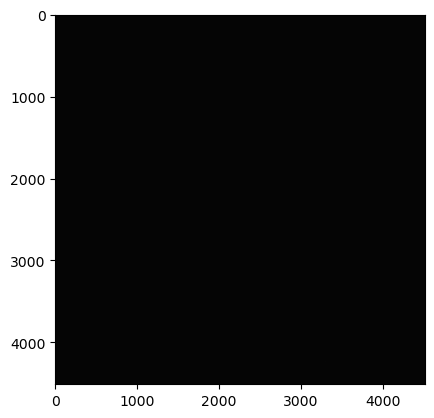

In [10]:
plt.imshow(data, cmap='gray');